# Growth-Spurt 📈
### The best-looking number on the list (Sharpe 0.835) — on real, tradable stocks

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates on large caps?: Not supported](https://img.shields.io/badge/Replicates_on_large_caps%3F-Not_supported-8b949e?style=flat-square)

The asset-growth effect — buy firms that grow their assets *slowly*, short the fast growers — carries the highest headline Sharpe in the whole vendor backlog. We rebuild it on real balance-sheet data (total assets from SEC filings, used only once they were actually filed) for large, liquid stocks. The famous premium is **nowhere to be measured**: the hedge is a statistical zero (-3.4%/yr, 95% CI [-9.3%, +2.5%]) — on a panel whose survivorship bias, as we'll see, leans *against* the effect.

> 📓 **Plain-language layer.** The construction, the CI and the three explanations are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it, from the fingerprinted run in [`../docs/results.md`](../docs/results.md) (as-of 2026-06-01, fp `8dec74717e92`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (growth_spurt/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from growth_spurt import data, strategy as st
# Real panel, cache-first (built by examples/verify.py --fetch): EDGAR Assets + Yahoo
# July->June returns, formed June 30 of y+1 on 10-Ks already FILED by then (no look-ahead),
# prices pinned to the desk as-of; the in-progress window is excluded.
ag, fwd = data.fetch_panel()
h = st.quantile_hedge(ag, fwd, q=0.2)
mkt = st.market_annual(fwd).reindex(h.index)


## The answer first 🎯

| The pitch | On tradable large caps |
|---|---|
| "Slow growers beat fast growers (Sharpe 0.835)" | The hedge earns **-3.4%/yr**, 95% CI **[-9.3%, +2.5%]** — indistinguishable from zero on 15 years. |
| "A robust accounting anomaly" | Not measurable here — and our survivor universe is biased *against* it (the delisted high-growth blow-ups the short leg needed are gone), so the slightly negative sign means nothing. |
| "Just sort and hold" | The effect, where the literature finds it, hides in micro-caps you can't trade at scale. |

## 1 · The claim

Cooper, Gulen & Schill (2008): companies that expand their balance sheets fast — big capex, acquisitions, share issuance — subsequently disappoint, while frugal firms outperform. Sort on year-on-year **total-asset growth**, long the bottom, short the top.

## 2 · So what?

A 0.835 Sharpe from a number every company files annually would be a gift. But headline Sharpes from accounting anomalies famously come from the market's smallest, least tradable names. Does this one survive where you could actually put money?

## 3 · How would we even know?

Pull **real total assets from SEC EDGAR** for ~400 large-cap names, compute each firm's fiscal-year asset growth, and form the book **on June 30 of the following year, using only 10-Ks already filed by then** — the paper's own convention, so we never trade on a number before the market saw it. Long the slowest fifth, short the fastest, hold July→June, and measure the hedge with its **confidence interval** — fifteen yearly observations deserve error bars, not adjectives.

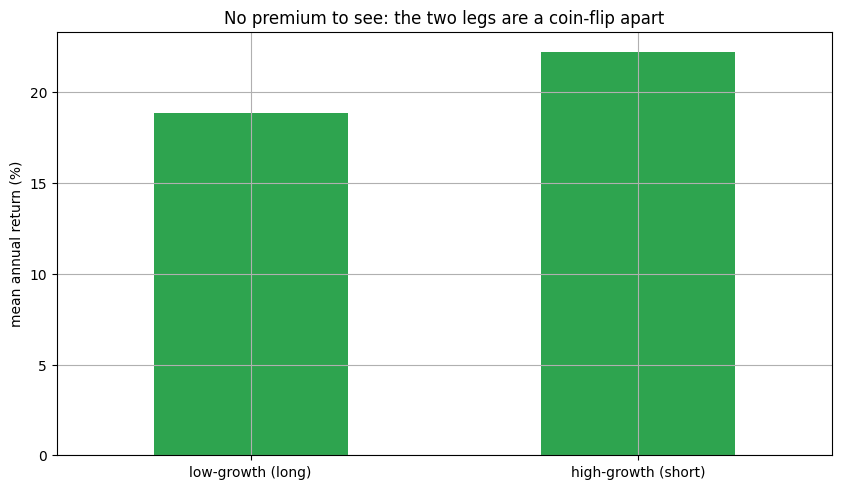

hedge (low - high): -3.39%/yr  95% CI [-9.3%, +2.5%]  Sharpe -0.32  (n=15 years)


In [2]:
leg = pd.DataFrame({'low-growth (long)':[st.summary(h['low_growth'])['mean']],
                    'high-growth (short)':[st.summary(h['high_growth'])['mean']]}, index=['mean annual return'])
ax = (leg.T*100).plot.bar(legend=False, rot=0, color=['#2ea44f','#c0392b'],
        title='No premium to see: the two legs are a coin-flip apart')
ax.set_ylabel('mean annual return (%)'); plt.show()
s = st.summary(h['hedge'])
print('hedge (low - high): %+.2f%%/yr  95%% CI [%+.1f%%, %+.1f%%]  Sharpe %.2f  (n=%d years)'
      % (s['mean']*100, s['ci95_low']*100, s['ci95_high']*100, s['sharpe'], s['n']))

## 4 · The teardown

The long-short earns nothing reliable over July 2010 → June 2025 — the mean is slightly negative, but the error bars swallow it whole. And one thing we must *not* conclude: that the effect runs backwards. Our universe is today's S&P 500 — the high-growth firms that grew themselves off a cliff and got delisted are exactly the ones a survivor list deletes, and they were the short leg's best trades. That censoring **props up the short leg** and drags the hedge *down*: the deck is stacked against the strategy here, so a negative point estimate is exactly what noise plus that bias would produce.

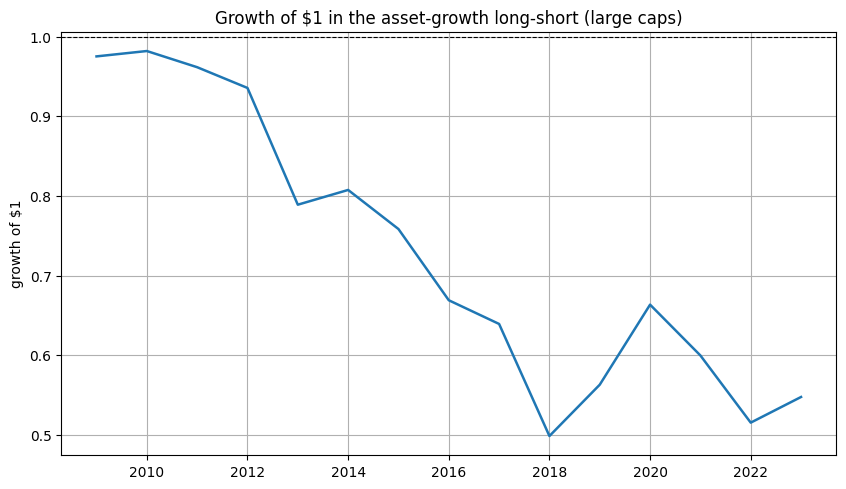

In [3]:
eq=(1+h['hedge']).cumprod()
ax=eq.plot(title='Growth of $1 in the asset-growth long-short (large caps)',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1'); plt.show()

**Read it plainly.** A line that drifts without conviction. The vendor's 0.835 came from a corner of the market — tiny, illiquid stocks — that a tradable strategy can't reach. Move to names you could hold and there is no premium left to measure; and because our panel censors the short leg's disasters, even the drift's *direction* tells you nothing.

## 5 · The verdict

**Signal: None** — no measurable premium on tradable large caps (-3.4%/yr, CI [-9.3%, +2.5%]; a modest premium can't be ruled out on 15 yearly observations). **Tradability: Mirage** — 0.835 lives where you can't trade. **Replicates on large caps?: Not supported** — and since the panel is biased *against* the effect, that's a failure to find, not a disproof.

## 6 · Could you actually trade it?

Not the headline version. To get the advertised Sharpe you'd need to short hundreds of micro-caps — wide spreads, hard-to-borrow, and the exact names most prone to survivorship and data errors. The liquid version has nothing measurable to pay you.

## 7 · Going further 🚪

The quants notebook gives the three reasons (micro-cap concentration, the investment factor, the survivorship direction) and the numbers. Next: [Study 45 Vanishing-Act](../../45-vanishing-act/) — the size premium, the anomaly that *defined* post-publication decay.